# 01 — Measurement quality

Coverage, warmup/contamination, sequential-stopping convergence, estimator choice, run-to-run dispersion, achieved-iteration and cardinality-agreement tables.

Reads the **cached DuckDB tables directly** (no Azure). Outputs land in `figures/` (PNG, thesis names) and `tables/` (`\input` fragments). Run with the repo root as cwd and no other kernel holding `cache/bench-cache.duckdb`.

In [1]:
import os, shutil
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
import pandas as pd
from src.plotting.style import StyleConfig
from src.plotting.charts import plot_coverage_heatmap
from src.analysis import thesis_compute as tc
from src.analysis import thesis_tables as tt
from src.plotting import thesis_figures as tf

style = StyleConfig(); style.apply_rcparams()
CACHE = os.environ.get("DOPPA_CACHE", "cache/bench-cache.duckdb")
RUN_ID = "2026-05-26-OY0CN3"
FIG = Path("figures"); TAB = Path("tables")
REP_QUERY = "point-in-polygon-lookup-duckdb-small"  # representative cold-start query

experiments, samples_df, metadata_df, costs_df, successful = tc.load_all(
    CACHE, "../doppa/benchmarks.yml", RUN_ID)
print("successful samples:", successful.shape)

successful samples: (394834, 26)


## Coverage grid → `06-results-coverage.png` (`fig:results-coverage`)
Reuses `plot_coverage_heatmap`; copied to the thesis filename.

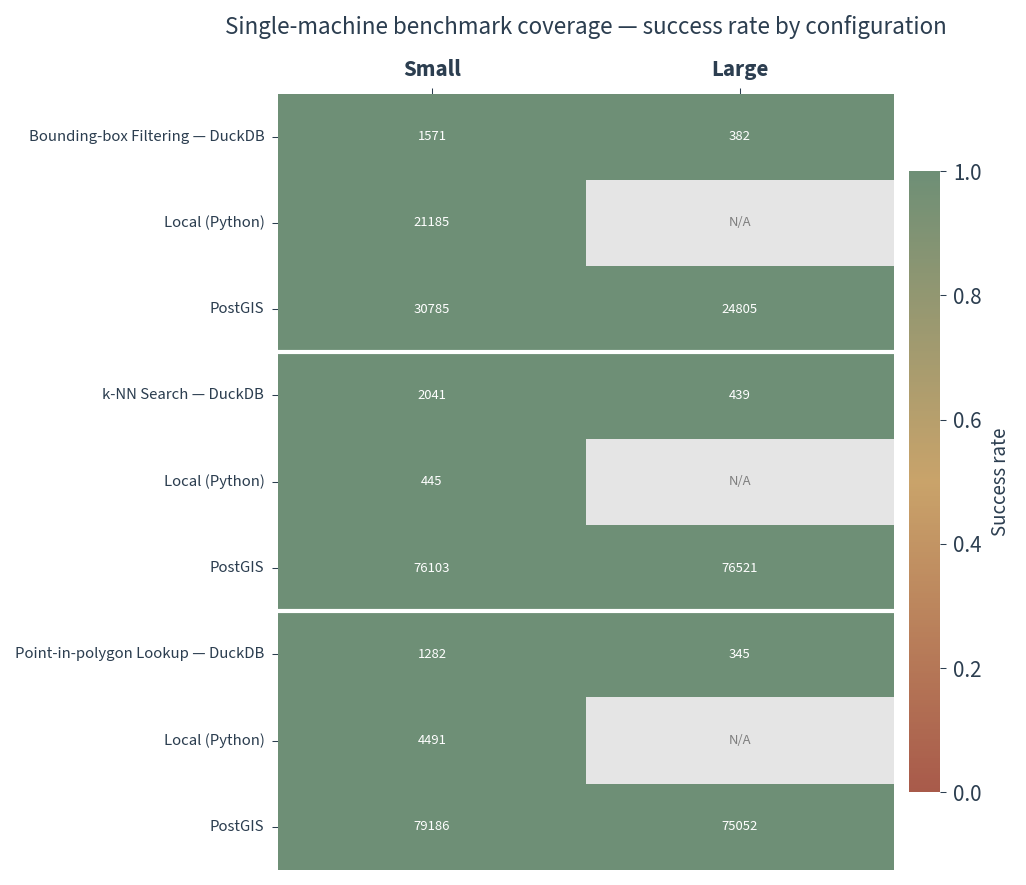

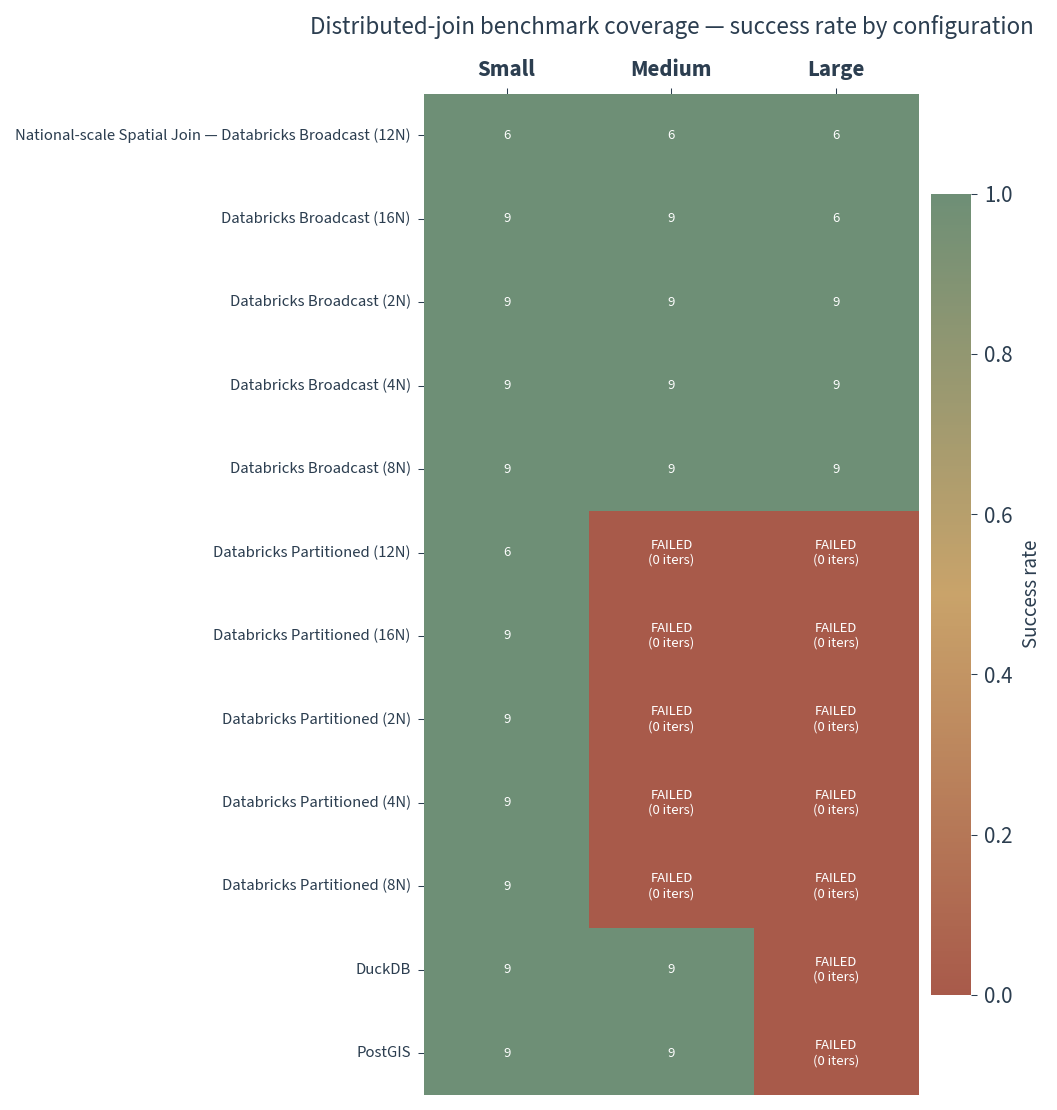

In [2]:
RQ1_COVERAGE = ["point-in-polygon-lookup", "knn-search", "bbox-filtering"]
RQ2_COVERAGE = ["national-scale-spatial-join"]
plot_coverage_heatmap(samples_df, successful, style, FIG,
                      metadata_df=metadata_df, experiments=experiments,
                      workloads=RQ1_COVERAGE,
                      out_name="06-results-coverage-single-machine",
                      title="Single-machine benchmark coverage — success rate by configuration",
                      transpose=True)
plot_coverage_heatmap(samples_df, successful, style, FIG,
                      metadata_df=metadata_df, experiments=experiments,
                      workloads=RQ2_COVERAGE,
                      out_name="06-results-coverage-distributed",
                      title="Distributed-join benchmark coverage — success rate by configuration",
                      transpose=True)

## Warmup, convergence, estimator (results §1 + appendix)

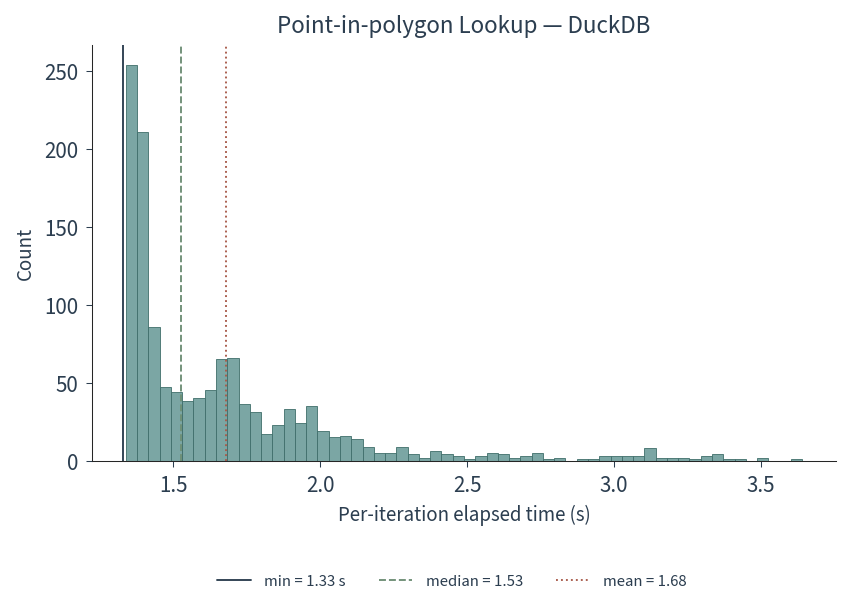

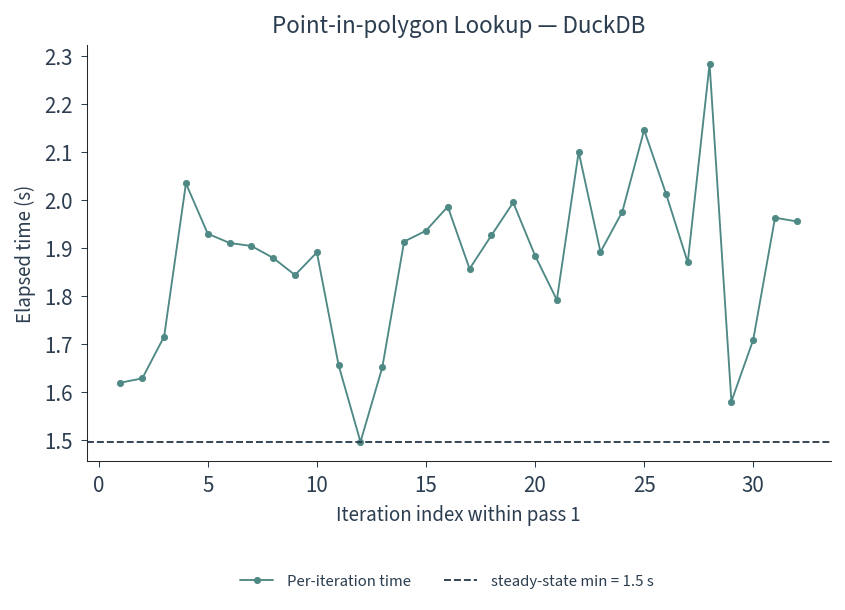

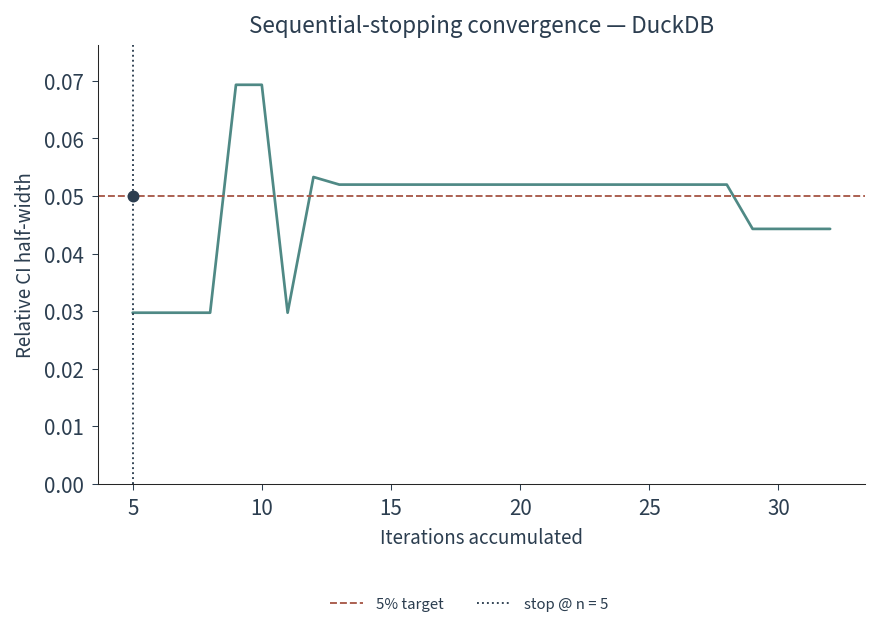

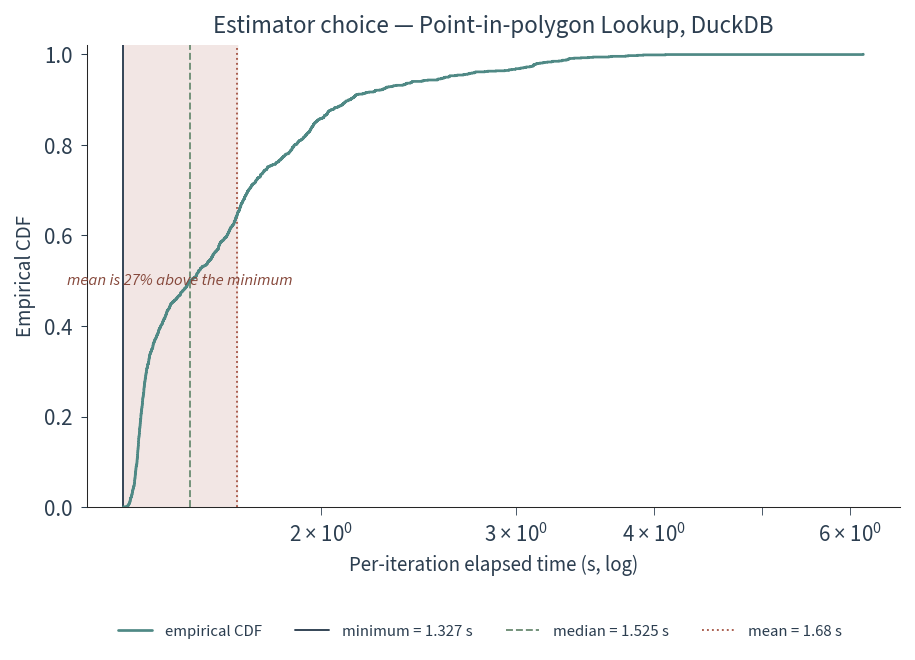

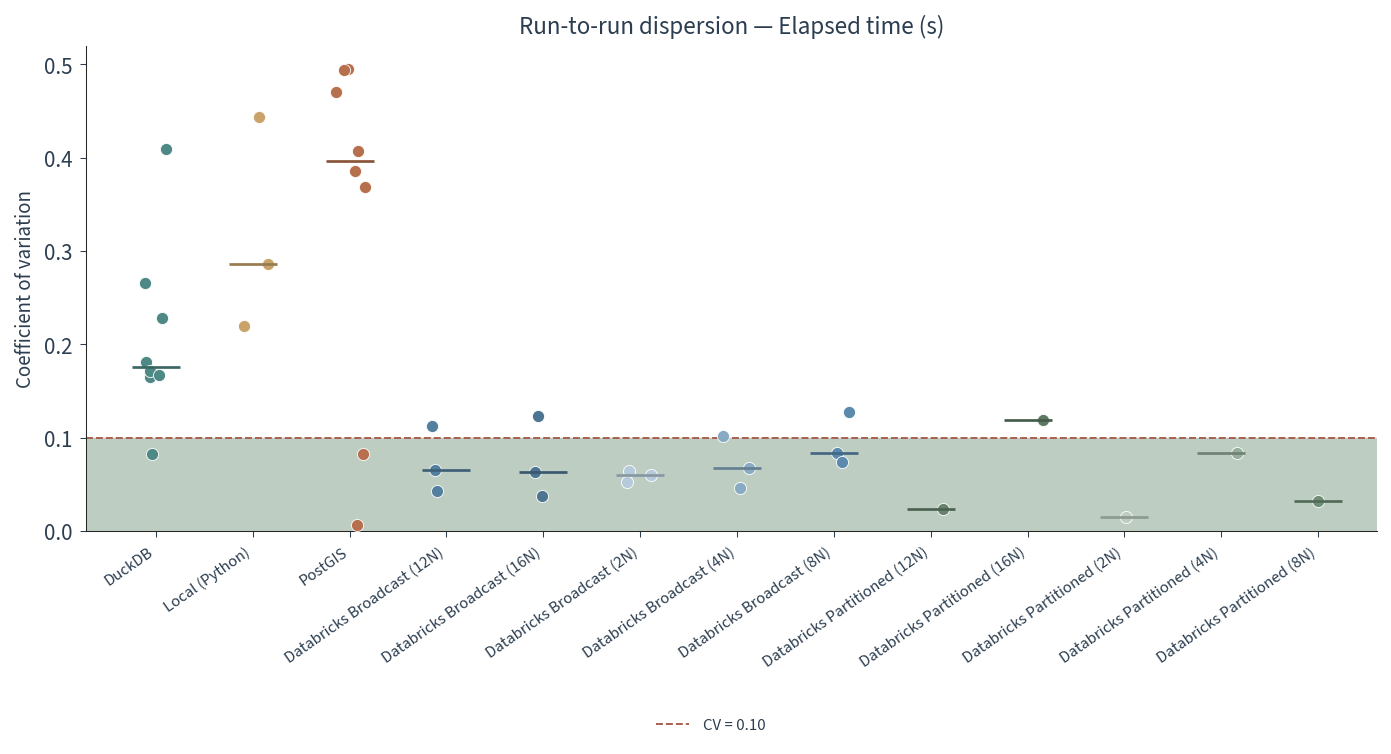

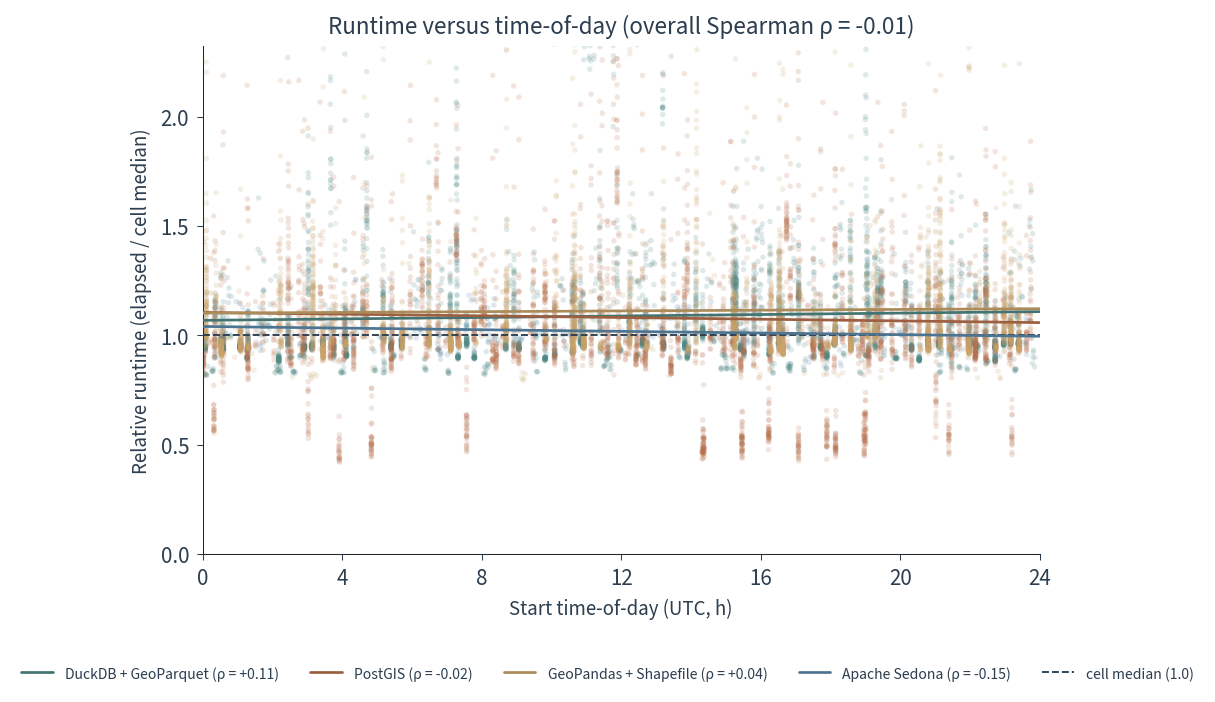

PosixPath('figures/08-time-of-day-stability.png')

In [3]:
tf.fig_warmup_distribution(successful, REP_QUERY, style, FIG / "06-results-warmup-distribution.png")
tf.fig_warmup_decay(successful, REP_QUERY, style, FIG / "06-results-warmup-decay.png")
tf.fig_convergence(successful, REP_QUERY, style, FIG / "06-results-convergence.png")
tf.fig_estimator_illustration(successful, REP_QUERY, style, FIG / "09-estimator-illustration.png")
tf.fig_cv_dispersion(successful, style, FIG / "09-cv-dispersion.png")
# Appendix: time-of-day / noisy-neighbour stability check (no thesis float yet — see report)
tf.fig_time_of_day_stability(successful, style, FIG / "08-time-of-day-stability.png")

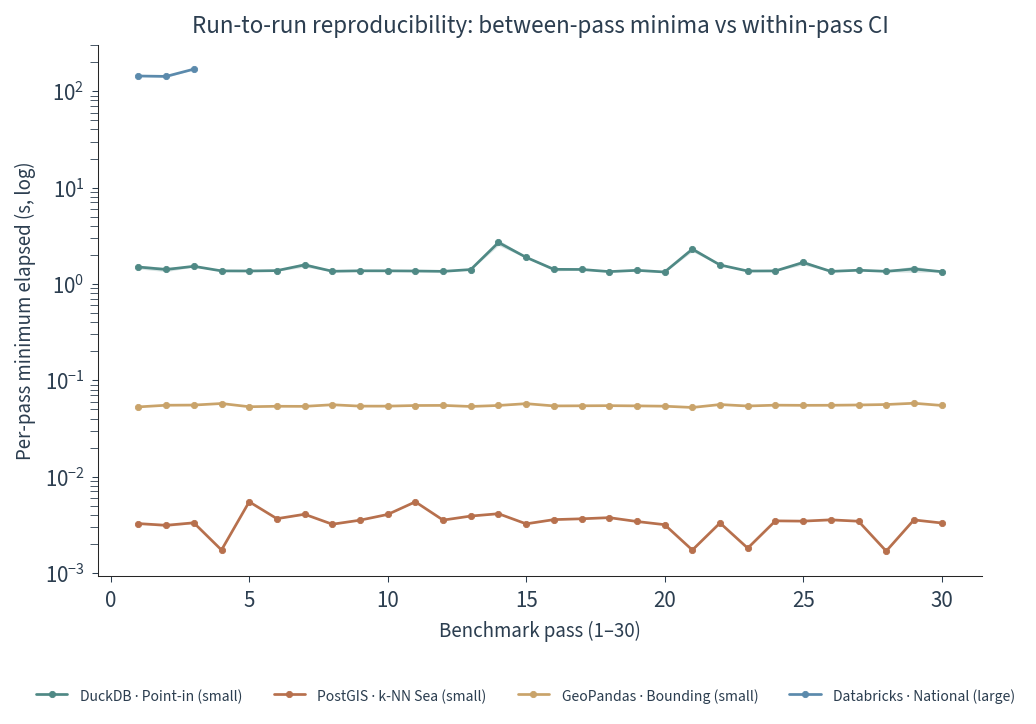

PosixPath('figures/09-reproducibility.png')

In [4]:
# --- New appendix figure: run-to-run reproducibility ---
tf.fig_reproducibility(successful, style, FIG / "09-reproducibility.png")

## Tables: achieved iterations + cardinality agreement

In [5]:
tt.emit_achieved_n(successful, metadata_df, experiments, TAB / "06-achieved-iterations.tex")
card = tc.cardinality_agreement(successful)
tt.emit_cardinality(card, TAB / "08-cardinality-agreement.tex")
# Fuller per-cell dispersion companion to the lean achieved-n table (no float yet — see report)
summ = tt.emit_summary_statistics(successful, experiments, TAB / "08-summary-statistics.tex")
display(summ)
card

,workload_type,configuration,dataset_size,n,min_s,median_s,iqr_s,cv,ci_halfwidth_pct
0,point-in-polygon-lookup,duckdb,small,1282,1.327399,1.525217,0.407092,0.265214,0.451221
1,point-in-polygon-lookup,duckdb,large,345,29.919312,36.873121,10.035440,0.167240,0.453289
2,point-in-polygon-lookup,postgis,small,79186,0.001606,0.003723,0.000953,0.407367,3.762457
3,point-in-polygon-lookup,postgis,large,75052,0.001489,0.003930,0.001053,0.494092,1.229513
4,point-in-polygon-lookup,local,small,4491,0.342664,0.374062,0.075094,0.219808,0.111808
5,knn-search,duckdb,small,2041,0.746047,0.804419,0.166365,0.228632,0.061164
6,knn-search,duckdb,large,439,15.736374,17.678940,6.249419,0.408922,0.191353
7,knn-search,postgis,small,76103,0.001683,0.004150,0.001131,0.495126,1.865176
8,knn-search,postgis,large,76521,0.001617,0.003935,0.001064,0.469907,1.178651
9,knn-search,local,small,445,47.816031,60.809975,19.397265,0.285781,0.412122


,wt_tier,duckdb,postgis,local,max_rel_disc
4,"Bounding-box, small",2723.0,2682.0,-1.0,0.015287
5,"Bounding-box, large",3015.0,2970.0,NaN,0.015152
2,"kNN, small",10.0,10.0,10.0,0.000000
3,"kNN, large",10.0,10.0,NaN,0.000000
6,"National join, small",357.0,357.0,NaN,0.000000
7,"National join, medium",357.0,357.0,NaN,0.000000
0,"Point-in-polygon, small",1.0,1.0,1.0,0.000000
1,"Point-in-polygon, large",1.0,1.0,NaN,0.000000
